<a href="https://colab.research.google.com/github/tolumeadows/ai-portrait-pipeline/blob/main/Diffuser_stuff_idk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from diffusers import AutoPipelineForText2Image # allows us to easily do text to image stuff
from diffusers.utils import load_image # allows us to load images with urls
import torch # needed for specifying numeric precision later on

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


In [ ]:
pipeline = AutoPipelineForText2Image.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    safety_checker=None,
    requires_safety_checker=False,
    torch_dtype=torch.float16).to("cuda") # this inputs the diffusion model from hugging face we want, runnning it on 16 bit acc for quickness and on the gpu we have.

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [ ]:
pipeline.load_ip_adapter( # this adds on to our pipeline a code that allows us to input images to generate images, in combination with our baseline text-to-image
    "h94/IP-Adapter", subfolder="models", weight_name="ip-adapter-full-face_sd15.bin"
)

models/ip-adapter-full-face_sd15.bin: reconstructing file:   0%|          |  0.00B / 43.6MB            

models/ip-adapter-full-face_sd15.bin: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

models/image_encoder/model.safetensors: reconstructing file:   0%|          |  0.00B / 2.53GB            

models/image_encoder/model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

There are modules in UNet2DConditionModel that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


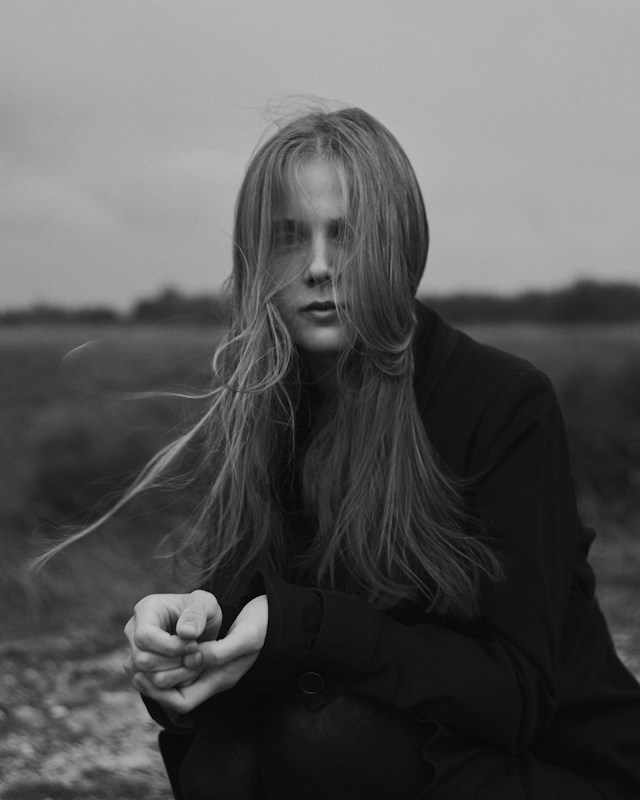

In [ ]:
# image = load_image("/content/alina-chernovolova-CupJvkGjGGE-unsplash.jpg")
# image = load_image("/content/alina-chernovolova-KwdnBzW8ixA-unsplash.jpg")
# image = load_image("/christian-agbede-_PfE8dZSPUs-unsplash.jpg")
image = load_image("/content/alina-chernovolova-CupJvkGjGGE-unsplash.jpg")
image

In [ ]:
pipeline.set_ip_adapter_scale(.3) # sets the strengths of the inputed image to 0.8 and not the full 1. or to whatever if i change it.

In [ ]:
# for seed_img in range(1,3):
#   output = pipeline( # runs with the pipeline installs above
#       prompt="a zoomed out full body portrait in medieval armor, renaissance painting style. the background is a desert landscape.", # prompt
#       ip_adapter_image=image, # takes in the image we set to "image" above
#       negative_prompt="low quality, blurry", # negative prompt the pipeline should avoid
#       num_inference_steps=50, # the number of steps of denoising to get to the image
#       height=640,
#       width=512,
#       generator=torch.Generator("cuda").manual_seed(seed_img) # manually sets the random starting static to the same each time since the starting noise/static is generated by a "random" number generator
#   ).images[0] # this pipline would return a list of images, but we take just the first one

#   final= output.resize((750,1000))
#   display(final)

In [ ]:
# I LIKE THIS MORE RIGHT NOW. MY OWN!

# output = pipeline( # runs with the pipeline installs above
#     prompt="a zoomed out full body portrait in medieval armor, renaissance painting style. the background is a desert landscape.", # prompt
#     ip_adapter_image=image, # takes in the image we set to "image" above
#     negative_prompt="low quality, blurry", # negative prompt the pipeline should avoid
#     num_inference_steps=50, # the number of steps of denoising to get to the image
#     height=640,
#     width=512,
#     generator=torch.Generator("cuda").manual_seed(42) # manually sets the random starting static to the same each time since the starting noise/static is generated by a "random" number generator
# ).images[0] # this pipline would return a list of images, but we take just the first one

# final= output.resize((750,1000))
# display(final)

# WHAT CLAUDE SAID WAS BETTER.

pipeline.set_ip_adapter_scale(0.7)

for seed in range(1, 5):
    output = pipeline(
        prompt="a waist-up portrait in medieval armor, renaissance painting style, desert landscape background",
        ip_adapter_image=image,
        negative_prompt="low quality, blurry",
        num_inference_steps=30,
        height=640,
        width=512,
        generator=torch.Generator("cuda").manual_seed(seed),
    ).images[0]
    print("seed", seed)
    display(output)

In [5]:
import torch
from diffusers import AutoPipelineForText2Image, DDIMScheduler
from transformers import CLIPVisionModelWithProjection
image_encoder = CLIPVisionModelWithProjection.from_pretrained( # this reads the inputed image and converts it to numbers that describe the photo
    "h94/IP-Adapter", #where the image encoder project lives
    subfolder = "models/image_encoder",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True
)

pipeline = AutoPipelineForText2Image.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5", #where the image generation model lives, which allows us to generate the output images
    torch_dtype=torch.float16, # sets the size the weights of the model are stored in after loading
    variant="fp16", # this selects for the halfsized files (the files have a 32int and 16 in version) fom the image v1-5 files
    use_safetensors=True, # akes sure no harmful code is taken from the v1-5 files by only taking the .safetensor files which are no code and all raw numbers

    pipeline.scheduler==DDIMscheduler.from_config(pipeline.scheduler.config) # replaces the old scheduler that determines how to slowly remove the static with the old scheduler's settings but a new class
).to("cuda") # loads it on gpu

pipeline.load_ip_adapter( # connects an ip adapter to the pipeline which allows images (which the image decoder converts to numbers) to be passed through the image generator.
                          # this also steers the final image to look like the inputed image
  "h94/IP-Adapter", # find the repo where the ip adapter lives
  subfolder = "models",
  weight_name = "ip-adapter-plus-face_sd15.safetensors" # the plus face one**
)

pipeline.set_ip_adapter_scale(.6) # sets how much the ip adapter should steer the final image from the inputed image



SyntaxError: positional argument follows keyword argument (4093137479.py, line 18)

  0%|          | 0/30 [00:00<?, ?it/s]

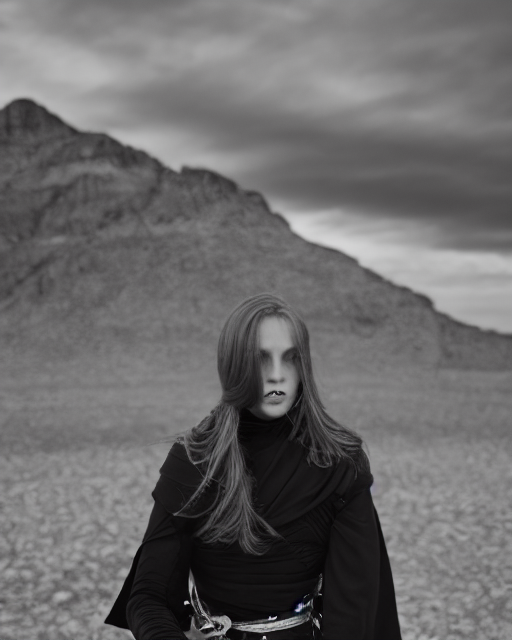

In [ ]:
generator = torch.Generator("cuda").manual_seed(1)
output = pipeline(
    prompt="a waist-up portrait in medieval armor, renaissance painting style, desert landscape background",
    ip_adapter_image=image,
    negative_prompt="low quality, blurry",
    num_inference_steps=30,
    height=640, width=512,
    generator=generator,
).images[0]
display(output)